In [8]:
from tensorflow.keras.datasets import mnist
import numpy as np
import matplotlib.pyplot as plt
from model import create_model

In [24]:
(x1,y1), (x2, y2) = mnist.load_data()

x1 = x1/255.0
x1 = np.expand_dims(x1, axis=-1)

x2 = x2/255.0
x2 = np.expand_dims(x2, axis=-1)

training_3 = []
training_5 = []

for i in range(x1.shape[0]):
    if y1[i] == 3:
        training_3.append(x1[i])
    
    if y1[i] == 5:
        training_5.append(x1[i]) 
training_3 = np.asarray(training_3)
training_5 = np.asarray(training_5)
training_3_5 = np.concatenate([training_3, training_5])    
indices = np.random.random_integers(0, len(training_3_5), size=10)
test_3_5 = [training_3_5[i] for i in indices]
test_3_5 = np.asarray(test_3_5)

         

/var/folders/p2/2ptx4x1d0fg58ffrcqrmwfsm0000gn/T/ipykernel_22999/2585930826.py:21: DeprecationWarning: This function is deprecated. Please call randint(0, 11552 + 1) instead
  indices = np.random.random_integers(0, len(training_3_5), size=10)


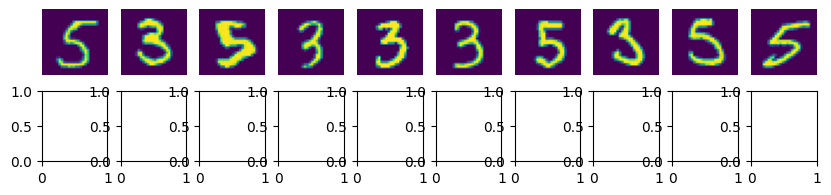

In [25]:
fig, ax = plt.subplots(2, 10, figsize=(10, 2))
ax = ax.flatten()

for i in range(10):
    ax[i].imshow(test_3_5[i])
    ax[i].axis('off')

plt.show()

In [44]:
(height, width, depth) = training_3.shape[1:]
(_, _, model) = create_model(height,width, depth, (32, 64), 32)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(training_3, training_3, epochs=10, batch_size=256)

Epoch 1/10


/var/folders/p2/2ptx4x1d0fg58ffrcqrmwfsm0000gn/T/ipykernel_22999/3802317114.py:2: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  (_, _, model) = create_model(height,width, depth, (32, 64), 32)


24/24 ━━━━━━━━━━━━━━━━━━━━ 21s 754ms/step - accuracy: 0.6719 - loss: 0.4981
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 749ms/step - accuracy: 0.7658 - loss: 0.2421
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 749ms/step - accuracy: 0.7719 - loss: 0.2298
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 748ms/step - accuracy: 0.7787 - loss: 0.1997
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 751ms/step - accuracy: 0.7853 - loss: 0.1733
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 748ms/step - accuracy: 0.7873 - loss: 0.1645
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 18s 752ms/step - accuracy: 0.7884 - loss: 0.1507
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 775ms/step - accuracy: 0.7904 - loss: 0.1414
Epoch 9/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 823ms/step - accuracy: 0.7929 - loss: 0.1316
Epoch 10/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 19s 778ms/step - accuracy: 0.7936 - loss: 0.1252


In [45]:
predictions = model.predict(test_3_5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step


In [52]:
errors = []
# loop over all original images and their corresponding
# reconstructions
for (image, recon) in zip(test_3_5, predictions):
	# compute the mean squared error between the ground-truth image
	# and the reconstructed image, then add it to our list of errors
	mse = np.mean((image - recon) ** 2)
	errors.append(mse)

# compute the q-th quantile of the errors which serves as our
# threshold to identify anomalies -- any data point that our model
# reconstructed with > threshold error will be marked as an outlier
thresh = np.percentile(errors, 95)
idxs = np.where(np.array(errors) >= thresh)[0]
print("[INFO] mse threshold: {}".format(thresh))
print("[INFO] {} outliers found".format(len(idxs)))

[INFO] mse threshold: 0.04383086624883771
[INFO] 1 outliers found


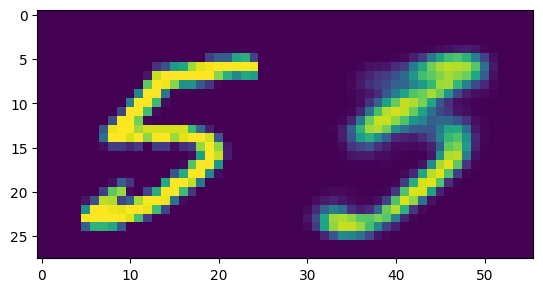

In [53]:
outputs = None
for i in idxs:
    orig = test_3_5[i]
    predicted = predictions[i]
    output = np.hstack([orig, predicted])
    if outputs is None:
        outputs = output
    else:    
        outputs = np.vstack([outputs, output])
    
plt.imshow(outputs)
plt.show()

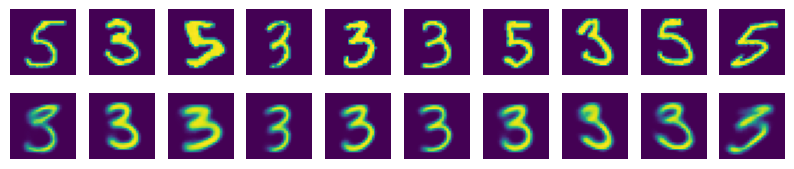

In [54]:
fig, ax = plt.subplots(2, 10, figsize=(10, 2))
ax = ax.flatten()
n=10
for i in range(n):
    ax[i].imshow(test_3_5[i])
    ax[i].axis('off')

    ax[i+n].imshow(predictions[i])
    ax[i+n].axis('off')
plt.show()